In [91]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [6]:
url = "https://api.opendota.com/api/publicMatches"

response = requests.get(url, timeout=30)

print("Status code:", response.status_code)
print("Response type:", response.headers.get("content-type"))

Status code: 200
Response type: application/json; charset=utf-8


In [10]:
matches = response.json()

print("Data type:", type(matches))
print("Number of matches returned:", len(matches))

#to show the fields of the data , to know what to use in our analysis
print(matches[0].keys())

Data type: <class 'list'>
Number of matches returned: 100
dict_keys(['match_id', 'match_seq_num', 'radiant_win', 'start_time', 'duration', 'lobby_type', 'game_mode', 'avg_rank_tier', 'num_rank_tier', 'cluster', 'radiant_team', 'dire_team'])


In [11]:
#convert the list into panda df
df_test = pd.DataFrame(matches)
#display
df_test.head()

,match_id,match_seq_num,radiant_win,start_time,duration,lobby_type,game_mode,avg_rank_tier,num_rank_tier,cluster,radiant_team,dire_team
0,8900428978,7481211764,False,1784281382,0,14,13,64,1,414,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
1,8900423282,7481207395,False,1784281017,0,14,13,75,2,271,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
2,8900421948,7481206124,False,1784280932,0,4,1,52,1,423,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
3,8900421914,7481206724,False,1784280932,0,14,13,31,4,153,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
4,8900421161,7481205522,False,1784280877,0,4,1,35,1,413,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"


In [16]:
print("Dataset shape:", df_test.shape)

print("Nb of matches",df_test.shape[0])

print("nb of coulmns",df_test.shape[1])

Dataset shape: (100, 12)
Nb of matches 100
nb of coulmns 12


In [18]:
# Create an empty list
all_matches = []

number_of_requests = 20

# At the beginning, we do not have a match ID
last_match_id = None

for request_number in range(number_of_requests):

    #first request
    if last_match_id is None:
        url = "https://api.opendota.com/api/publicMatches"

    # matches older than the last match
    else:
      url = "https://api.opendota.com/api/publicMatches?less_than_match_id=" + str(last_match_id)


    response = requests.get(url, timeout=30)
    if response.status_code == 200:

        new_matches = response.json()
        all_matches.extend(new_matches)


        last_match_id = min(match["match_id"] for match in new_matches)

        print(
            "Request",
            request_number + 1,
            "- Matches collected:",
            len(all_matches)
        )

    else:


        print("Request failed with status code:", response.status_code)


        break

    time.sleep(1)

Request 1 - Matches collected: 100
Request 2 - Matches collected: 200
Request 3 - Matches collected: 300
Request 4 - Matches collected: 400
Request 5 - Matches collected: 500
Request 6 - Matches collected: 600
Request 7 - Matches collected: 700
Request 8 - Matches collected: 800
Request 9 - Matches collected: 900
Request 10 - Matches collected: 1000
Request 11 - Matches collected: 1100
Request 12 - Matches collected: 1200
Request 13 - Matches collected: 1300
Request 14 - Matches collected: 1400
Request 15 - Matches collected: 1500
Request 16 - Matches collected: 1600
Request 17 - Matches collected: 1700
Request 18 - Matches collected: 1800
Request 19 - Matches collected: 1900
Request 20 - Matches collected: 2000


In [21]:
raw_df = pd.DataFrame(all_matches)

print("dataset shape", raw_df.shape)
print("nb of matches", raw_df.shape[0])
print("nb of matches",raw_df.shape[1])

raw_df.head()

dataset shape (2000, 12)
nb of matches 2000
nb of matches 12


,match_id,match_seq_num,radiant_win,start_time,duration,lobby_type,game_mode,avg_rank_tier,num_rank_tier,cluster,radiant_team,dire_team
0,8900477265,7481252274,False,1784284293,0,14,13,53,1,184,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
1,8900476639,7481252437,False,1784284258,0,14,13,31,1,151,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
2,8900473015,7481249689,False,1784284051,0,14,13,22,1,182,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
3,8900472658,7481248493,False,1784284026,0,4,1,25,1,118,"[0, 0, 0, 0, 0]","[0, 0, 0, 0, 0]"
4,8900471840,7481254380,True,1784283977,390,0,23,43,6,415,"[90, 18, 38, 81, 66]","[42, 86, 6, 64, 3]"


In [22]:
nb_of_duplicates = raw_df["match_id"].duplicated().sum()
print("nb of duplicates is ", nb_of_duplicates)

#each dota match has a unique id, but we check for duplicates

nb of duplicates is  0


In [26]:
raw_df.tail()
# we use tail here to verify that all the data is imported


,match_id,match_seq_num,radiant_win,start_time,duration,lobby_type,game_mode,avg_rank_tier,num_rank_tier,cluster,radiant_team,dire_team
1995,8900445804,7481249697,True,1784282432,1553,0,23,44,6,184,"[15, 101, 27, 61, 74]","[14, 4, 84, 5, 22]"
1996,8900445803,7481254625,False,1784282432,1802,7,22,43,2,413,"[62, 110, 12, 42, 26]","[22, 55, 8, 7, 108]"
1997,8900445802,7481245059,True,1784282417,1250,0,23,25,1,184,"[63, 48, 113, 101, 4]","[52, 9, 2, 25, 18]"
1998,8900445796,7481247003,False,1784282437,1385,0,23,33,1,183,"[104, 64, 22, 9, 44]","[121, 42, 14, 112, 58]"
1999,8900445794,7481252339,True,1784282432,1693,7,22,62,4,151,"[7, 106, 85, 35, 36]","[138, 21, 26, 23, 30]"


In [27]:
raw_df.info()
# to get info about the df we are working with

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   match_id       2000 non-null   int64 
 1   match_seq_num  2000 non-null   int64 
 2   radiant_win    2000 non-null   bool  
 3   start_time     2000 non-null   int64 
 4   duration       2000 non-null   int64 
 5   lobby_type     2000 non-null   int64 
 6   game_mode      2000 non-null   int64 
 7   avg_rank_tier  2000 non-null   int64 
 8   num_rank_tier  2000 non-null   int64 
 9   cluster        2000 non-null   int64 
 10  radiant_team   2000 non-null   object
 11  dire_team      2000 non-null   object
dtypes: bool(1), int64(9), object(2)
memory usage: 174.0+ KB


In [29]:
raw_df.describe()
#to generate descriptive stats

,match_id,match_seq_num,start_time,duration,lobby_type,game_mode,avg_rank_tier,num_rank_tier,cluster
count,2.000000e+03,2.000000e+03,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.00000
mean,8.900452e+09,7.481249e+09,1.784283e+09,1149.344000,1.149000,18.574500,40.86450,3.245000,227.12700
std,4.905789e+03,4.110103e+03,2.926645e+02,337.204187,2.217263,8.680848,15.17845,1.912539,90.36854
min,8.900446e+09,7.481232e+09,1.784282e+09,0.000000,0.000000,1.000000,11.00000,1.000000,117.00000
25%,8.900448e+09,7.481247e+09,1.784283e+09,949.000000,0.000000,22.000000,31.00000,2.000000,181.00000
50%,8.900451e+09,7.481250e+09,1.784283e+09,1197.000000,0.000000,23.000000,42.00000,3.000000,184.00000
75%,8.900455e+09,7.481253e+09,1.784283e+09,1389.000000,0.000000,23.000000,52.00000,5.000000,272.00000
max,8.900477e+09,7.481255e+09,1.784284e+09,1927.000000,14.000000,23.000000,75.00000,10.000000,423.00000


In [31]:
missing_values = raw_df.isnull().sum()

missing_values
# to check and display for any  missing values

,0
match_id,0
match_seq_num,0
radiant_win,0
start_time,0
duration,0
lobby_type,0
game_mode,0
avg_rank_tier,0
num_rank_tier,0
cluster,0


In [32]:
raw_df.columns
#to help visualize which variables to use

Index(['match_id', 'match_seq_num', 'radiant_win', 'start_time', 'duration',
       'lobby_type', 'game_mode', 'avg_rank_tier', 'num_rank_tier', 'cluster',
       'radiant_team', 'dire_team'],
      dtype='object')

In [36]:
new_df = raw_df.copy()

new_df= new_df.drop(columns=["match_seq_num","radiant_team","dire_team"])

new_df.head()
#for this code we copy the original dataset into a new one , and drop the mentioned columns which we will not use


,match_id,radiant_win,start_time,duration,lobby_type,game_mode,avg_rank_tier,num_rank_tier,cluster
0,8900477265,False,1784284293,0,14,13,53,1,184
1,8900476639,False,1784284258,0,14,13,31,1,151
2,8900473015,False,1784284051,0,14,13,22,1,182
3,8900472658,False,1784284026,0,4,1,25,1,118
4,8900471840,True,1784283977,390,0,23,43,6,415


In [37]:
new_df["radiant_win"]= new_df["radiant_win"].astype(int)
new_df.head()

,match_id,radiant_win,start_time,duration,lobby_type,game_mode,avg_rank_tier,num_rank_tier,cluster
0,8900477265,0,1784284293,0,14,13,53,1,184
1,8900476639,0,1784284258,0,14,13,31,1,151
2,8900473015,0,1784284051,0,14,13,22,1,182
3,8900472658,0,1784284026,0,4,1,25,1,118
4,8900471840,1,1784283977,390,0,23,43,6,415


In [40]:
print(new_df["radiant_win"].unique())
# we verify it's converted to binary 1 for the radiant win and 0 for dire win

[0 1]


In [47]:
new_df["duration_minutes"] = new_df["duration"] / 60

new_df[["duration", "duration_minutes"]].head()
# we convert the duration from seconds to mins

,duration,duration_minutes
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,390,6.5


In [52]:
new_df["match_date"] = pd.to_datetime(
    new_df["start_time"],
    unit="s"
)


new_df[["start_time", "match_date"]].head()
#convert to readable time stamp

,start_time,match_date
0,1784284293,2026-07-17 10:31:33
1,1784284258,2026-07-17 10:30:58
2,1784284051,2026-07-17 10:27:31
3,1784284026,2026-07-17 10:27:06
4,1784283977,2026-07-17 10:26:17


In [54]:
new_df["start_time"] = pd.to_datetime(new_df["start_time"], unit="s")
# to save the new time stamp

In [55]:
new_df.head()

,match_id,radiant_win,start_time,duration,lobby_type,game_mode,avg_rank_tier,num_rank_tier,cluster,duration_mins,duration_minutes,match_date
0,8900477265,0,2026-07-17 10:31:33,0,14,13,53,1,184,0.0,0.0,2026-07-17 10:31:33
1,8900476639,0,2026-07-17 10:30:58,0,14,13,31,1,151,0.0,0.0,2026-07-17 10:30:58
2,8900473015,0,2026-07-17 10:27:31,0,14,13,22,1,182,0.0,0.0,2026-07-17 10:27:31
3,8900472658,0,2026-07-17 10:27:06,0,4,1,25,1,118,0.0,0.0,2026-07-17 10:27:06
4,8900471840,1,2026-07-17 10:26:17,390,0,23,43,6,415,6.5,6.5,2026-07-17 10:26:17


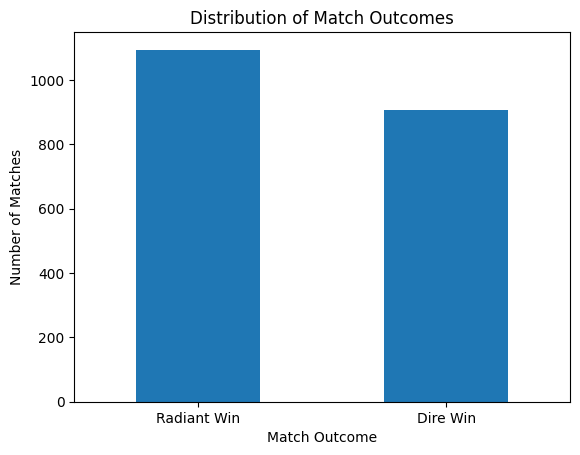

In [63]:
win_counts = new_df["radiant_win"].value_counts()


win_counts.plot(kind="bar")


plt.title("Distribution of Match Outcomes")
plt.xlabel("Match Outcome")
plt.ylabel("Number of Matches")

plt.xticks([0, 1], ["Radiant Win", "Dire Win"], rotation=0)

plt.show()


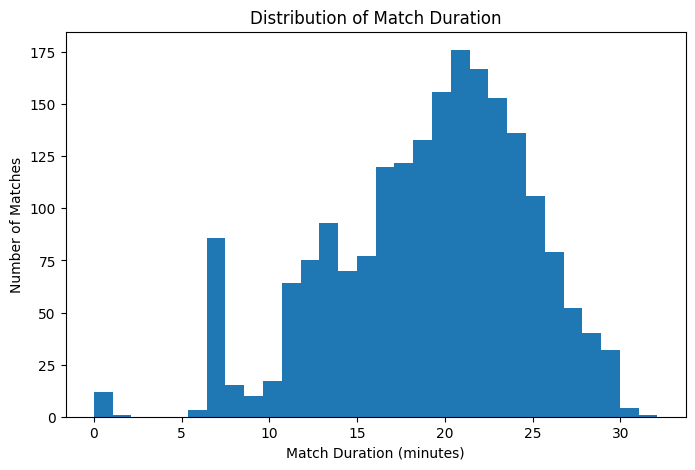

In [64]:
plt.figure(figsize=(8,5))

plt.hist(new_df["duration"] / 60, bins=30)

plt.title("Distribution of Match Duration")
plt.xlabel("Match Duration (minutes)")
plt.ylabel("Number of Matches")

plt.show()

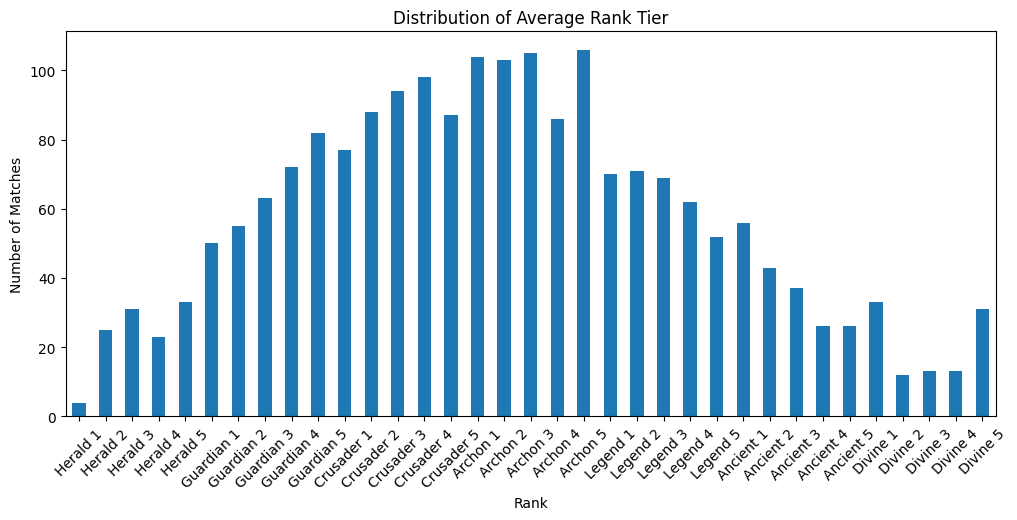

In [67]:
rank_names = {
    11: "Herald 1", 12: "Herald 2", 13: "Herald 3", 14: "Herald 4", 15: "Herald 5",
    21: "Guardian 1", 22: "Guardian 2", 23: "Guardian 3", 24: "Guardian 4", 25: "Guardian 5",
    31: "Crusader 1", 32: "Crusader 2", 33: "Crusader 3", 34: "Crusader 4", 35: "Crusader 5",
    41: "Archon 1", 42: "Archon 2", 43: "Archon 3", 44: "Archon 4", 45: "Archon 5",
    51: "Legend 1", 52: "Legend 2", 53: "Legend 3", 54: "Legend 4", 55: "Legend 5",
    61: "Ancient 1", 62: "Ancient 2", 63: "Ancient 3", 64: "Ancient 4", 65: "Ancient 5",
    71: "Divine 1", 72: "Divine 2", 73: "Divine 3", 74: "Divine 4", 75: "Divine 5",
    80: "Immortal"
}


rank_counts = new_df["avg_rank_tier"].value_counts().sort_index()
rank_counts.index = rank_counts.index.map(rank_names)

plt.figure(figsize=(12,5))

rank_counts.plot(kind="bar")

plt.title("Distribution of Average Rank Tier")
plt.xlabel("Rank")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)

plt.show()

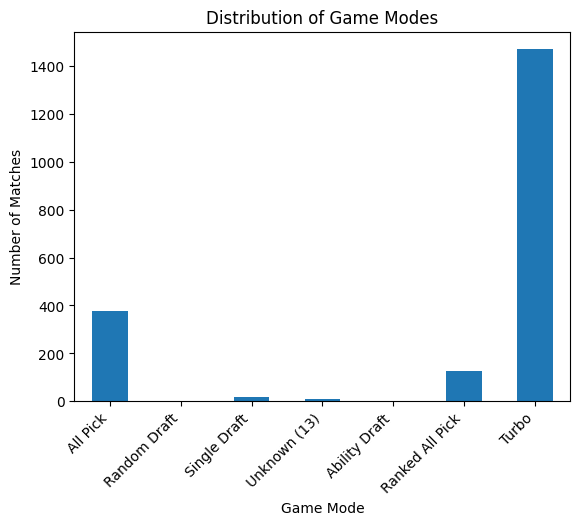

In [73]:
# Dictionary to convert game mode codes to names

game_modes = {
    1: "All Pick",
    2: "Captains Mode",
    3: "Random Draft",
    4: "Single Draft",
    5: "All Random",
    12: "Least Played",
    16: "Captains Draft",
    18: "Ability Draft",
    22: "Ranked All Pick",
    23: "Turbo"
}

game_mode_counts = new_df["game_mode"].value_counts().sort_index()

game_mode_counts.index = game_mode_counts.index.map(
    lambda x: game_modes.get(x, f"Unknown ({x})")
)

game_mode_counts.plot(kind="bar")

plt.title("Distribution of Game Modes")
plt.xlabel("Game Mode")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45, ha="right")

plt.show()

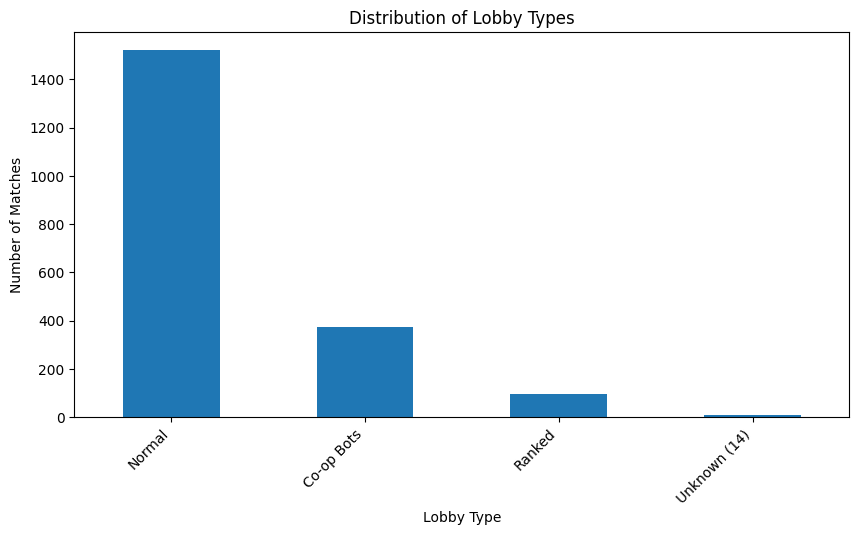

In [75]:

lobby_types = {
    0: "Normal",
    1: "Practice",
    2: "Tournament",
    3: "Tutorial",
    4: "Co-op Bots",
    5: "Ranked Team Matchmaking",
    6: "Ranked Solo Matchmaking",
    7: "Ranked",
    8: "One-on-One",
    9: "Battle Cup"
}

lobby_type_counts = new_df["lobby_type"].value_counts().sort_index()

lobby_type_counts.index = lobby_type_counts.index.map(
    lambda x: lobby_types.get(x, f"Unknown ({x})")
)


plt.figure(figsize=(10,5))

lobby_type_counts.plot(kind="bar")

plt.title("Distribution of Lobby Types")
plt.xlabel("Lobby Type")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45, ha="right")

plt.show()

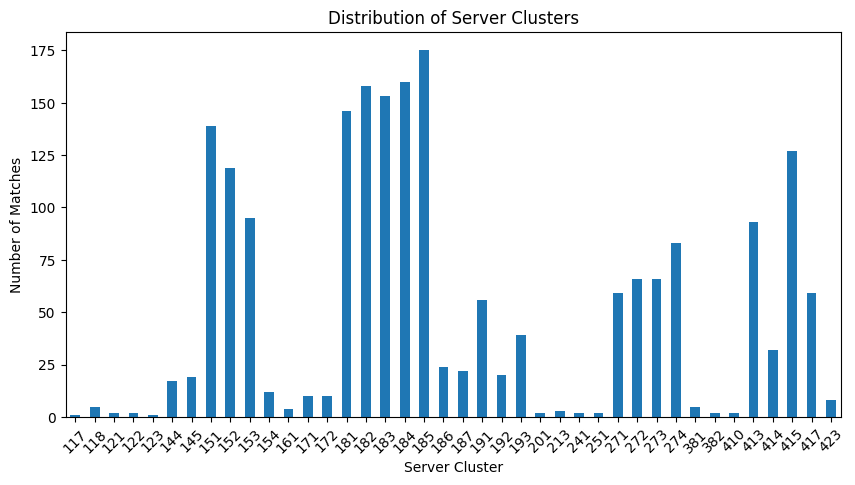

In [77]:


cluster_counts = new_df["cluster"].value_counts().sort_index()



plt.figure(figsize=(10,5))

cluster_counts.plot(kind="bar")

plt.title("Distribution of Server Clusters")
plt.xlabel("Server Cluster")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)

plt.show()

In [78]:
# Select the predictor variables

X = new_df[[
    "avg_rank_tier",
    "num_rank_tier",
    "game_mode",
    "lobby_type",
    "cluster"
]]

# Select the target variable

y = new_df["radiant_win"]

# Display the first rows

X.head()

,avg_rank_tier,num_rank_tier,game_mode,lobby_type,cluster
0,53,1,13,14,184
1,31,1,13,14,151
2,22,1,13,14,182
3,25,1,1,4,118
4,43,6,23,0,415


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1600, 5)
Testing set : (400, 5)


In [83]:
log_model = LogisticRegression(max_iter=1000)

# Train the model

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [85]:
y_pred = log_model.predict(X_test)

# Display the first 10 predictions

print(y_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


In [87]:

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5575


In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.10      0.16       175
           1       0.57      0.92      0.70       225

    accuracy                           0.56       400
   macro avg       0.52      0.51      0.43       400
weighted avg       0.52      0.56      0.46       400



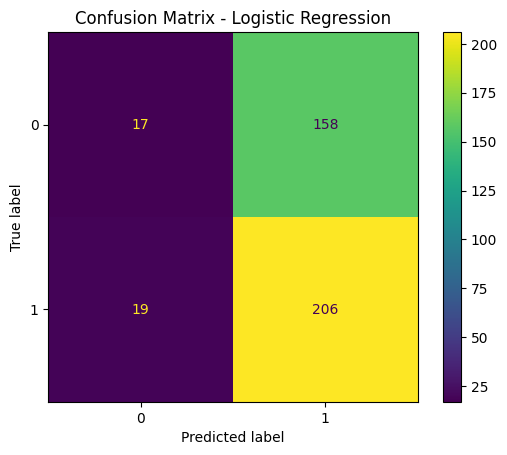

In [92]:
ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

the logistic regression with  55.75% accuracy indicating limited performance, it struggles to recognize dire victories , it means it has poor balance and another model could produce better predictive performance

In [94]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [97]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:10])

[0 1 0 1 0 0 0 1 0 1]


In [98]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.535


In [99]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.47      0.44      0.45       175
           1       0.58      0.61      0.60       225

    accuracy                           0.54       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.53      0.54      0.53       400



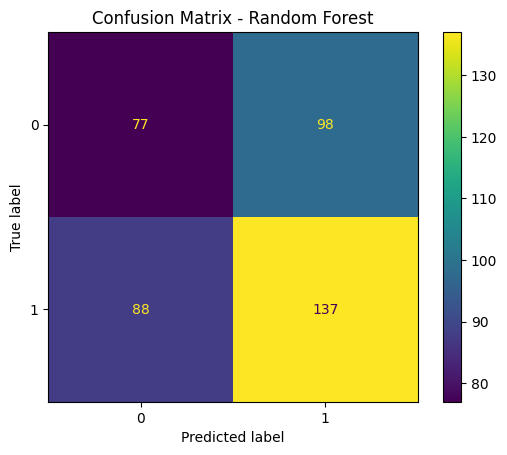

In [100]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [101]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest"],"Accuracy": [accuracy,rf_accuracy]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.5575
1,Random Forest,0.5350


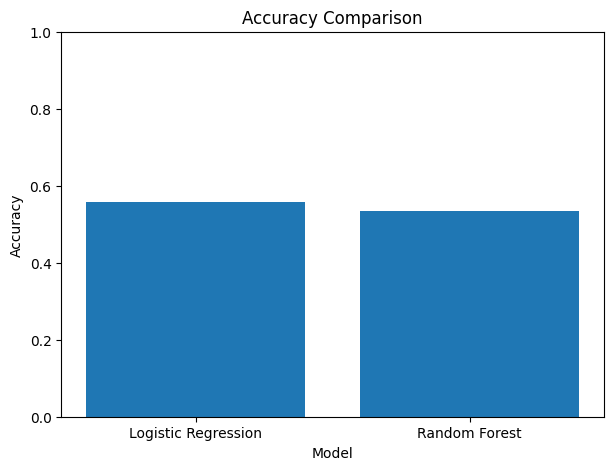

In [102]:
plt.figure(figsize=(7, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [96]:
features = X.columns

importance = rf_model.feature_importances_

importance_df = pd.DataFrame()

importance_df["Feature"] = features

importance_df["Importance"] = importance

# Sort

importance_df = importance_df.sort_values(by="Importance",ascending=False)

importance_df

,Feature,Importance
0,avg_rank_tier,0.421819
4,cluster,0.365680
1,num_rank_tier,0.161379
2,game_mode,0.029074
3,lobby_type,0.022048


In [105]:
if rf_accuracy > accuracy:
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    best_model = log_model
    best_model_name = "Logistic Regression"

print("Best model:", best_model_name)

Best model: Logistic Regression


In this project, I collected data from the OpenDota API and used it to predict if the Radiant team would win a match. First, I cleaned the data and explored it using different charts. Then, I trained two machine learning models and compared their results. The models were able to make predictions, but the accuracy was not very high because the dataset did not contain enough detailed information. Overall, this project helped me understand the complete machine learning process, from collecting data to building and evaluating models.

In [106]:
import joblib

joblib.dump(best_model, "dota2_prediction_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [107]:
joblib.dump(list(X.columns), "model_features.pkl")

print("Feature names saved successfully.")

Feature names saved successfully.


In [108]:
from google.colab import files

files.download("dota2_prediction_model.pkl")
files.download("model_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>